In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

df_final_dataset = pd.read_csv("data-analysis/final-ecommerce-dataset.csv")

#Revenue
df_revenue_by_month = pd.read_csv("data-analysis/revenue-by-month.csv")
df_revenue_by_category = pd.read_csv("data-analysis/revenue-by-category.csv")
df_revenue_by_customer_segment = pd.read_csv("data-analysis/revenue-by-customer-segment.csv")
df_revenue_per_state = pd.read_csv("data-analysis/revenue-per-state.csv")

#AOV
df_aov_by_category = pd.read_csv("data-analysis/aov-by-category.csv")
df_aov_by_customer_segment = pd.read_csv("data-analysis/aov-by-customer-segment.csv")
df_aov_by_month = pd.read_csv("data-analysis/aov-by-month.csv")

#Customer
df_customer_type_over_time = pd.read_csv("data-analysis/customer-type-over-time.csv")
df_customer_order_frequency_buckets = pd.read_csv("data-analysis/customer-order-frequency-buckets.csv")

#Category
df_growth_over_time = pd.read_csv("data-analysis/category-growth-over-time.csv")
df_retention_category_rate = pd.read_csv("data-analysis/retention-category-rate.csv")

#Seller
df_top_seller_of_review_delivery = pd.read_csv("data-analysis/top-seller-of-review-delivery.csv")

In [2]:
df_final_dataset.head()

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_id,customer_unique_id,customer_city,customer_state,order_item_id,...,product_length_cm,product_height_cm,product_width_cm,total_payment_value,payment_type,payment_installments,avg_review_score,revenue,delivery_days,late_delivery_flag
0,00018f77f2f0320c557190d7a144bdd3,delivered,2017-04-26 10:53:06+07,2017-05-12 16:04:24+07,2017-05-15 00:00:00+07,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,1,...,50.0,30.0,40.0,259.83,credit_card,3.0,4.0,259.83,16.0,0
1,000229ec398224ef6ca0657da4fc703e,delivered,2018-01-14 14:33:31+07,2018-01-22 13:19:16+07,2018-02-05 00:00:00+07,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,1,...,33.0,13.0,33.0,216.87,credit_card,5.0,5.0,216.87,7.0,0
2,00048cc3ae777c65dbb7d2a0634bc1ea,delivered,2017-05-15 21:42:34+07,2017-05-22 13:44:35+07,2017-06-06 00:00:00+07,816cbea969fe5b689b39cfc97a506742,85c835d128beae5b4ce8602c491bf385,uberaba,MG,1,...,24.0,8.0,15.0,34.59,boleto,1.0,4.0,34.59,6.0,0
3,0005a1a1728c9d785b8e2b08b904576c,delivered,2018-03-19 18:40:33+07,2018-03-29 18:17:31+07,2018-03-29 00:00:00+07,16150771dfd4776261284213b89c304e,639d23421f5517f69d0c3d6e6564cf0e,santos,SP,1,...,30.0,12.0,16.0,157.60,credit_card,3.0,1.0,157.60,9.0,1
4,00061f2a7bc09da83e415a52dc8a4af1,delivered,2018-03-24 22:16:10+07,2018-03-29 00:04:19+07,2018-04-09 00:00:00+07,c6fc061d86fab1e2b2eac259bac71a49,107e6259485efac66428a56f10801f4f,piracicaba,SP,1,...,35.0,25.0,20.0,68.87,credit_card,3.0,5.0,68.87,4.0,0


In [3]:
df_final_dataset.columns

Index(['order_id', 'order_status', 'order_purchase_timestamp',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_id', 'customer_unique_id', 'customer_city', 'customer_state',
       'order_item_id', 'product_id', 'seller_id', 'price', 'freight_value',
       'product_category_name', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'total_payment_value',
       'payment_type', 'payment_installments', 'avg_review_score', 'revenue',
       'delivery_days', 'late_delivery_flag'],
      dtype='object')

In [4]:
df_final_dataset.tail()

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_id,customer_unique_id,customer_city,customer_state,order_item_id,...,product_length_cm,product_height_cm,product_width_cm,total_payment_value,payment_type,payment_installments,avg_review_score,revenue,delivery_days,late_delivery_flag
112096,fff1e3e76b816bfe8ef16678cc53c643,delivered,2018-02-27 08:35:05+07,2018-03-07 14:49:33+07,2018-03-26 00:00:00+07,e194b91a5dac87c84cc54a7ed3fdad7a,66cd6da20c67f83a9cf37e01a0105812,recife,PE,1,...,50.0,40.0,30.0,86.85,credit_card,7.0,4.0,86.85,8.0,0
112097,fff6b8ca971f8e3ec822e99d0f2d3d21,delivered,2017-09-15 11:44:46+07,2017-09-21 19:34:19+07,2017-10-04 00:00:00+07,2aec499f94f5e82786629a84b816ffb9,c71a196d46a70ec611f3922db5755d1d,sao bernardo do campo,SP,1,...,20.0,7.0,14.0,215.83,credit_card,3.0,5.0,215.83,6.0,0
112098,fff8287bbae429a99bb7e8c21d151c41,delivered,2018-03-17 12:11:45+07,2018-04-07 10:07:48+07,2018-04-19 00:00:00+07,6c1e92a209dbf868706caa831090941e,028c09f007292c4e3a3b10d296e47987,joao pessoa,PB,1,...,20.0,20.0,20.0,456.28,credit_card,4.0,5.0,228.14,20.0,0
112099,fff8287bbae429a99bb7e8c21d151c41,delivered,2018-03-17 12:11:45+07,2018-04-07 10:07:48+07,2018-04-19 00:00:00+07,6c1e92a209dbf868706caa831090941e,028c09f007292c4e3a3b10d296e47987,joao pessoa,PB,2,...,20.0,20.0,20.0,456.28,credit_card,4.0,5.0,228.14,20.0,0
112100,fffa82886406ccf10c7b4e35c4ff2788,delivered,2017-12-18 16:33:07+07,2018-01-08 18:23:10+07,2018-01-24 00:00:00+07,a5201e1a6d71a8d21e869151bd5b4085,2a3ab9bf9639491997586882c502540a,tenente ananias,RN,1,...,60.0,15.0,15.0,273.92,credit_card,7.0,4.0,273.92,21.0,0


In [5]:
df_final_dataset.isnull().sum()

order_id                            0
order_status                        0
order_purchase_timestamp            0
order_delivered_customer_date    1912
order_estimated_delivery_date       0
customer_id                         0
customer_unique_id                  0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
price                               0
freight_value                       0
product_category_name            1589
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
total_payment_value                 3
payment_type                        3
payment_installments                3
avg_review_score                  925
revenue                             0
delivery_days                    1912
late_delivery_flag                  0
dtype: int64

In [6]:
df_final_dataset['order_id'].duplicated().sum()

np.int64(13902)

In [7]:
df_final_dataset['customer_unique_id'].duplicated().sum()

np.int64(17118)

In [8]:
df_final_dataset['product_id'].duplicated().sum()

np.int64(79372)

In [9]:
df_final_dataset = df_final_dataset.drop_duplicates(subset=['order_id','product_id','customer_unique_id'])

In [10]:
df_final_dataset.dropna(subset=['order_delivered_customer_date'], inplace=True)

In [11]:
df_final_dataset.isnull().sum()

order_id                            0
order_status                        0
order_purchase_timestamp            0
order_delivered_customer_date       0
order_estimated_delivery_date       0
customer_id                         0
customer_unique_id                  0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
price                               0
freight_value                       0
product_category_name            1401
product_weight_g                   16
product_length_cm                  16
product_height_cm                  16
product_width_cm                   16
total_payment_value                 1
payment_type                        1
payment_installments                1
avg_review_score                  693
revenue                             0
delivery_days                       0
late_delivery_flag                  0
dtype: int64

In [12]:
df_final_dataset.dropna(subset=['total_payment_value', 'payment_type', 'payment_installments'], inplace=True)

In [13]:
df_final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100187 entries, 0 to 112100
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       100187 non-null  object 
 1   order_status                   100187 non-null  object 
 2   order_purchase_timestamp       100187 non-null  object 
 3   order_delivered_customer_date  100187 non-null  object 
 4   order_estimated_delivery_date  100187 non-null  object 
 5   customer_id                    100187 non-null  object 
 6   customer_unique_id             100187 non-null  object 
 7   customer_city                  100187 non-null  object 
 8   customer_state                 100187 non-null  object 
 9   order_item_id                  100187 non-null  int64  
 10  product_id                     100187 non-null  object 
 11  seller_id                      100187 non-null  object 
 12  price                          1001

In [14]:
df_final_dataset['order_delivered_customer_date'] = pd.to_datetime(df_final_dataset['order_delivered_customer_date'])
df_final_dataset['order_estimated_delivery_date'] = pd.to_datetime(df_final_dataset['order_estimated_delivery_date'])
df_final_dataset['order_purchase_timestamp'] = pd.to_datetime(df_final_dataset['order_purchase_timestamp'])

In [15]:
df_final_dataset['product_category_name'].fillna(value=df_final_dataset['product_category_name'].mode()[0], inplace=True)
df_final_dataset['product_weight_g'].fillna(value=df_final_dataset['product_weight_g'].mode()[0], inplace=True)
df_final_dataset['product_length_cm'].fillna(value=df_final_dataset['product_length_cm'].mode()[0], inplace=True)
df_final_dataset['product_height_cm'].fillna(value=df_final_dataset['product_height_cm'].mode()[0], inplace=True)
df_final_dataset['product_width_cm'].fillna(value=df_final_dataset['product_width_cm'].mode()[0], inplace=True)
df_final_dataset['avg_review_score'].fillna(value=df_final_dataset['avg_review_score'].mode()[0], inplace=True)

In [16]:
df_final_dataset.isnull().sum()

order_id                         0
order_status                     0
order_purchase_timestamp         0
order_delivered_customer_date    0
order_estimated_delivery_date    0
customer_id                      0
customer_unique_id               0
customer_city                    0
customer_state                   0
order_item_id                    0
product_id                       0
seller_id                        0
price                            0
freight_value                    0
product_category_name            0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
total_payment_value              0
payment_type                     0
payment_installments             0
avg_review_score                 0
revenue                          0
delivery_days                    0
late_delivery_flag               0
dtype: int64

In [17]:
df_final_dataset.shape

(100187, 26)

In [18]:
df_final_dataset.columns

Index(['order_id', 'order_status', 'order_purchase_timestamp',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_id', 'customer_unique_id', 'customer_city', 'customer_state',
       'order_item_id', 'product_id', 'seller_id', 'price', 'freight_value',
       'product_category_name', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'total_payment_value',
       'payment_type', 'payment_installments', 'avg_review_score', 'revenue',
       'delivery_days', 'late_delivery_flag'],
      dtype='object')

In [19]:
df_final_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100187 entries, 0 to 112100
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype                    
---  ------                         --------------   -----                    
 0   order_id                       100187 non-null  object                   
 1   order_status                   100187 non-null  object                   
 2   order_purchase_timestamp       100187 non-null  datetime64[ns, UTC+07:00]
 3   order_delivered_customer_date  100187 non-null  datetime64[ns, UTC+07:00]
 4   order_estimated_delivery_date  100187 non-null  datetime64[ns, UTC+07:00]
 5   customer_id                    100187 non-null  object                   
 6   customer_unique_id             100187 non-null  object                   
 7   customer_city                  100187 non-null  object                   
 8   customer_state                 100187 non-null  object                   
 9   order_item_id       

In [20]:
corr_df = df_final_dataset.select_dtypes(include=['int64', 'float64'])
corr_matrix = corr_df.corr()

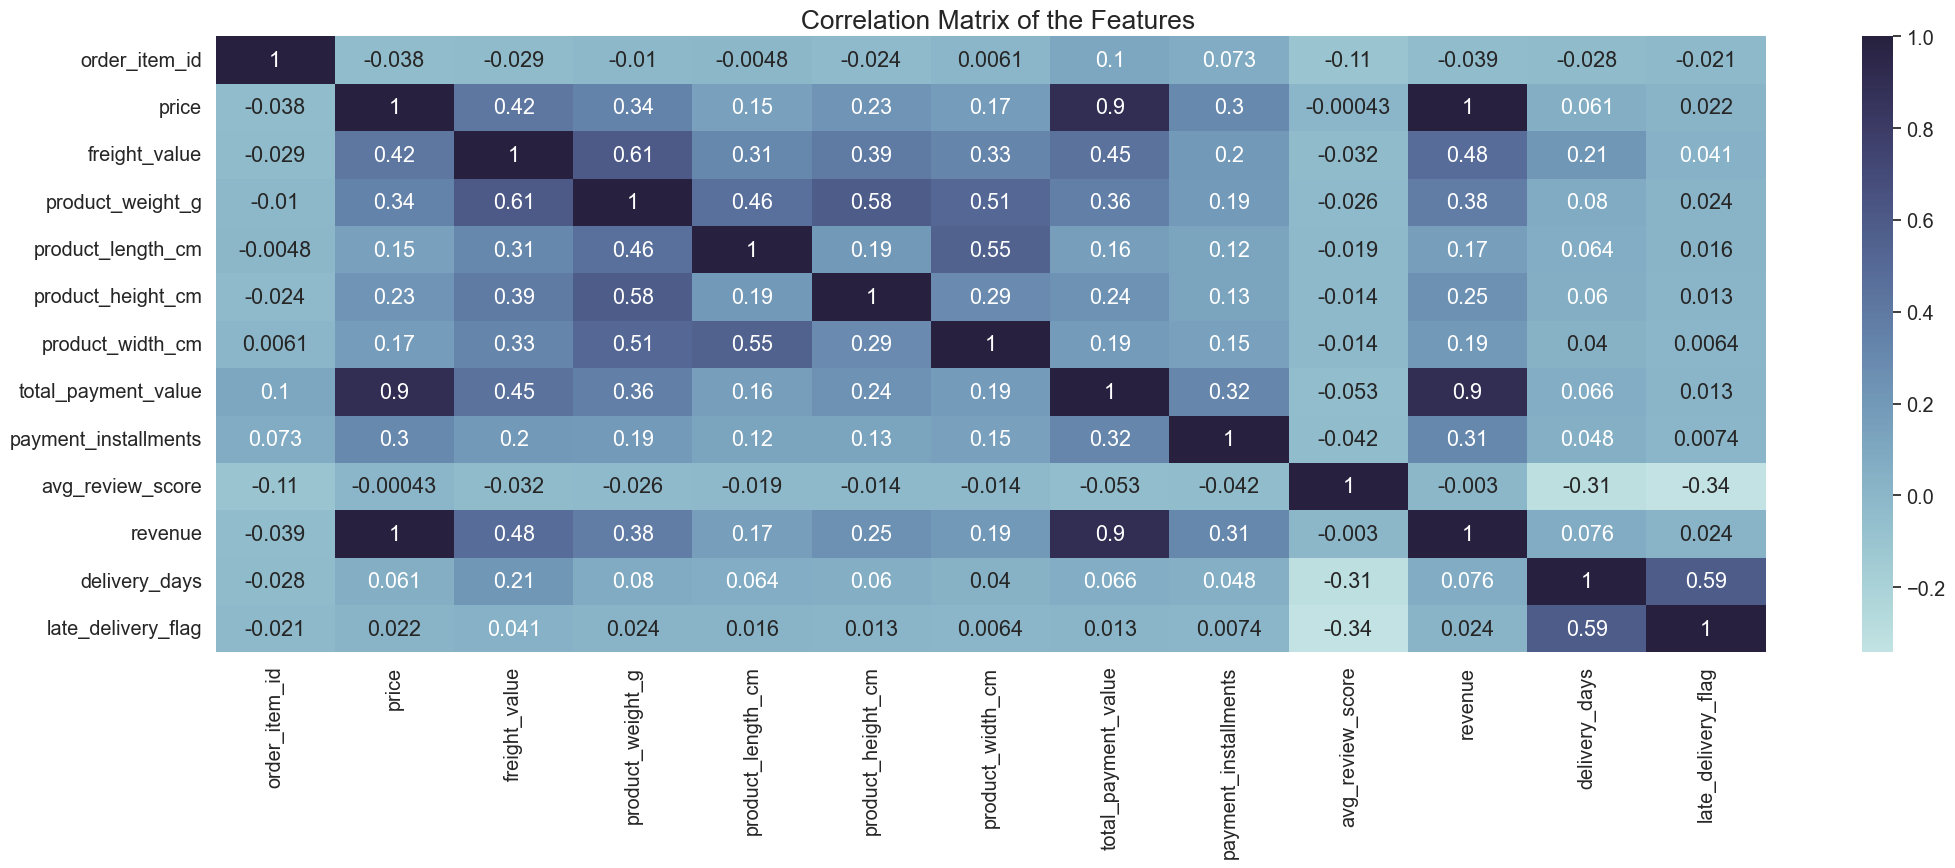

In [21]:
plt.figure(figsize=(25,8))
sns.set(font_scale=1.3)
cmap = sns.color_palette("ch:start=.2,rot=-.3", as_cmap=True)
sns.heatmap(corr_matrix, cmap=cmap,annot=True)
plt.title("  Correlation Matrix of the Features",fontsize=19)
plt.show()

In [22]:
df_revenue_by_month.head()

,month,revenue,quatily_order,mom
0,2016-09-01 00:00:00+07,136.23,1,NaN
1,2016-10-01 00:00:00+07,51657.53,293,37819.35
2,2016-12-01 00:00:00+07,19.62,1,-99.96
3,2017-01-01 00:00:00+07,137006.76,787,698201.53
4,2017-02-01 00:00:00+07,283621.94,1718,107.01


In [23]:
df_revenue_by_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   month          24 non-null     object 
 1   revenue        24 non-null     float64
 2   quatily_order  24 non-null     int64  
 3   mom            23 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 900.0+ bytes


In [24]:
df_revenue_by_month.isnull().sum()

month            0
revenue          0
quatily_order    0
mom              1
dtype: int64

In [25]:
df_revenue_by_month['mom'] = df_revenue_by_month['mom'].fillna(0)

In [26]:
df_revenue_by_month.isnull().sum()

month            0
revenue          0
quatily_order    0
mom              0
dtype: int64

In [27]:
df_revenue_by_month['month'] = pd.to_datetime(df_revenue_by_month['month'])

In [28]:
df_revenue_by_month['year_month'] = (df_revenue_by_month['month'].dt.to_period('M').astype(str)) 

In [29]:
df_revenue_by_month.head()

,month,revenue,quatily_order,mom,year_month
0,2016-09-01 00:00:00+07:00,136.23,1,0.00,2016-09
1,2016-10-01 00:00:00+07:00,51657.53,293,37819.35,2016-10
2,2016-12-01 00:00:00+07:00,19.62,1,-99.96,2016-12
3,2017-01-01 00:00:00+07:00,137006.76,787,698201.53,2017-01
4,2017-02-01 00:00:00+07:00,283621.94,1718,107.01,2017-02


In [30]:
df_revenue_by_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype                    
---  ------         --------------  -----                    
 0   month          24 non-null     datetime64[ns, UTC+07:00]
 1   revenue        24 non-null     float64                  
 2   quatily_order  24 non-null     int64                    
 3   mom            24 non-null     float64                  
 4   year_month     24 non-null     object                   
dtypes: datetime64[ns, UTC+07:00](1), float64(2), int64(1), object(1)
memory usage: 1.1+ KB


In [55]:
def bar_plot(x, y, df, colors = sns.color_palette("ch:s=.25,rot=-.25", n_colors=len(df_revenue_by_month)), hue=False, ax=None, value=False, title=''):
    # Preparing variables
    try:
        ncount = sum(df[y])
    except:
        ncount = sum(df[x])

    if hue != False:
        ax = sns.barplot(x=x, y=y, data=df, palette=colors, hue=hue, ax=ax, ci=None)
    else:
        ax = sns.barplot(x=x, y=y, data=df, palette=colors, ax=ax, ci=None)

    # Setting percentage
    for p in ax.patches:
        xp = p.get_bbox().get_points()[:, 0]
        yp = p.get_bbox().get_points()[1, 1]
        if value:
            ax.annotate('{:.2f}k'.format(yp/1000), (xp.mean(), yp), ha='center', va='bottom') # Set the alignment of the text
        else:
            ax.annotate('{:.1f}%'.format(100.*yp/ncount), (xp.mean(), yp), ha='center', va='bottom') # Set the alignment of the text
    plt.tight_layout()
    
def format_spines(ax, right_border=True):
    
    ax.spines['bottom'].set_color('#666666')
    ax.spines['left'].set_color('#666666')
    ax.spines['top'].set_visible(False)
    if right_border:
        ax.spines['right'].set_color('#FFFFFF')
    else:
        ax.spines['right'].set_color('#FFFFFF')
    ax.patch.set_facecolor('#FFFFFF')

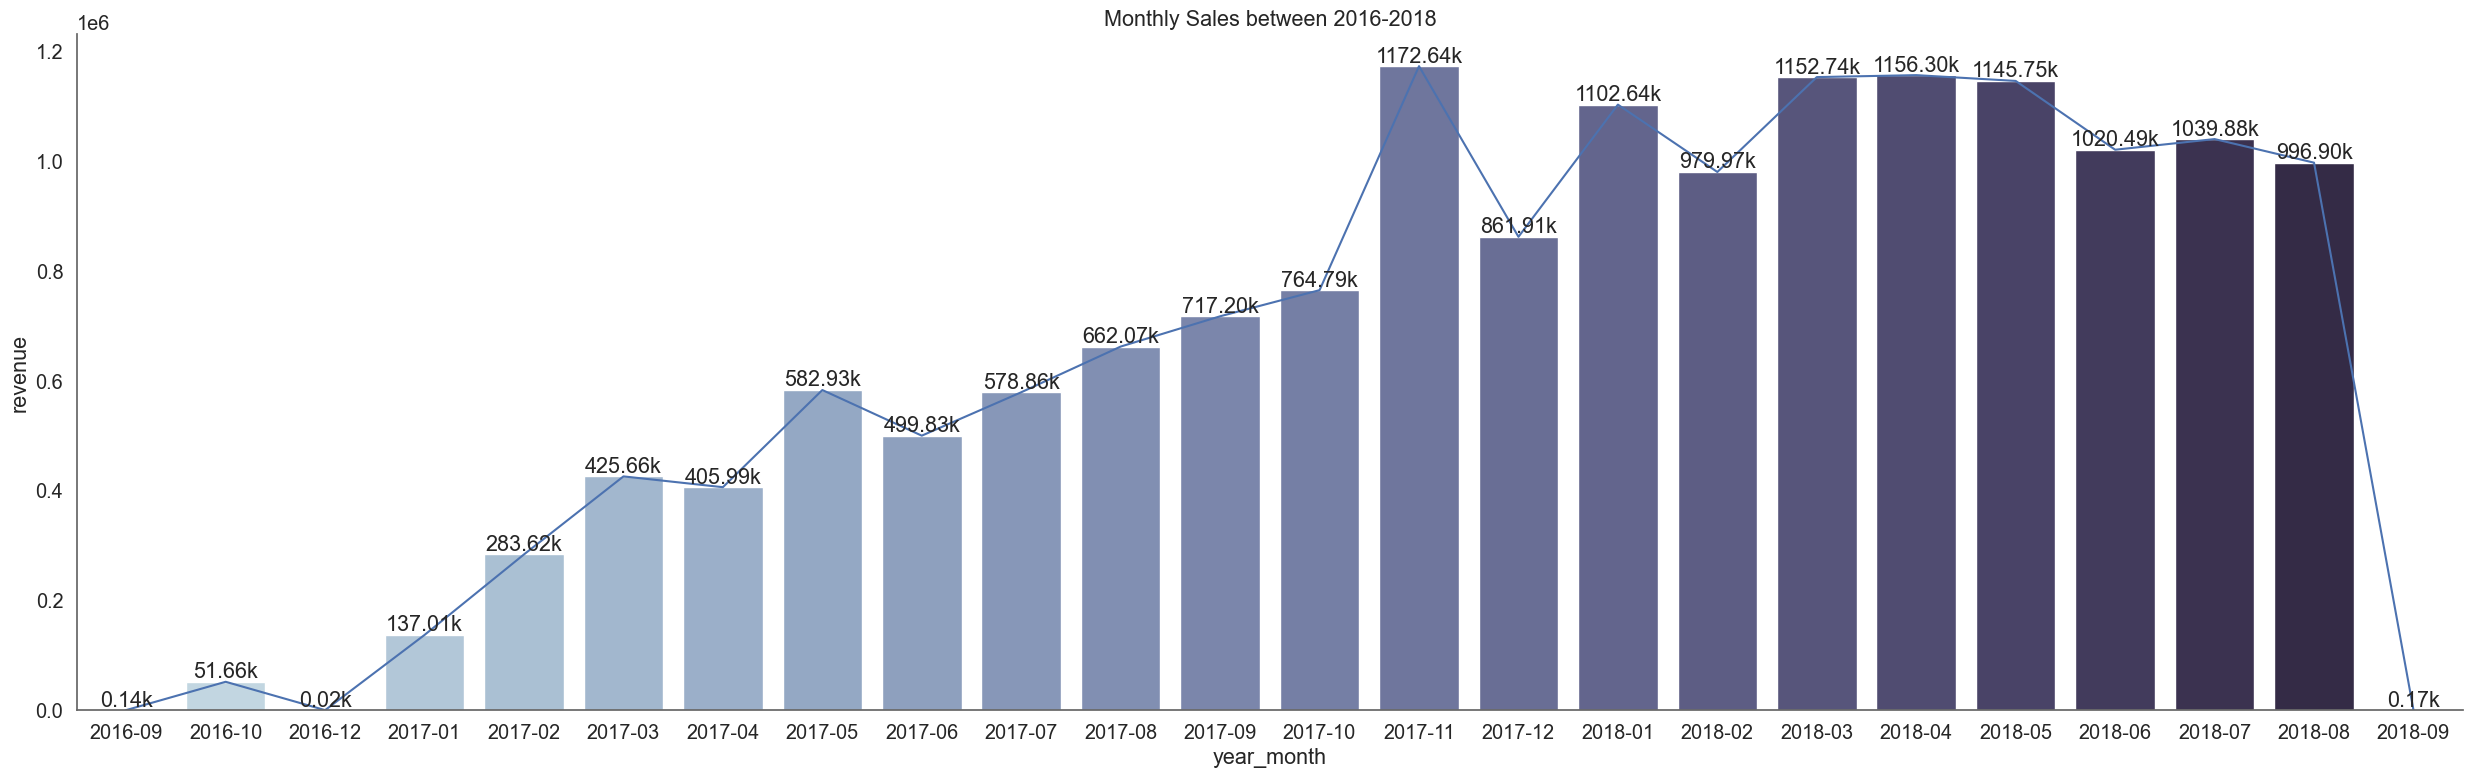

In [56]:
fig, ax = plt.subplots(figsize=(25, 8))
ax = sns.lineplot(x='year_month', y='revenue', data=df_revenue_by_month)
bar_plot(x='year_month', y='revenue', df=df_revenue_by_month, value=True)
format_spines(ax, right_border=False)
ax.set_title('Monthly Sales between 2016-2018');

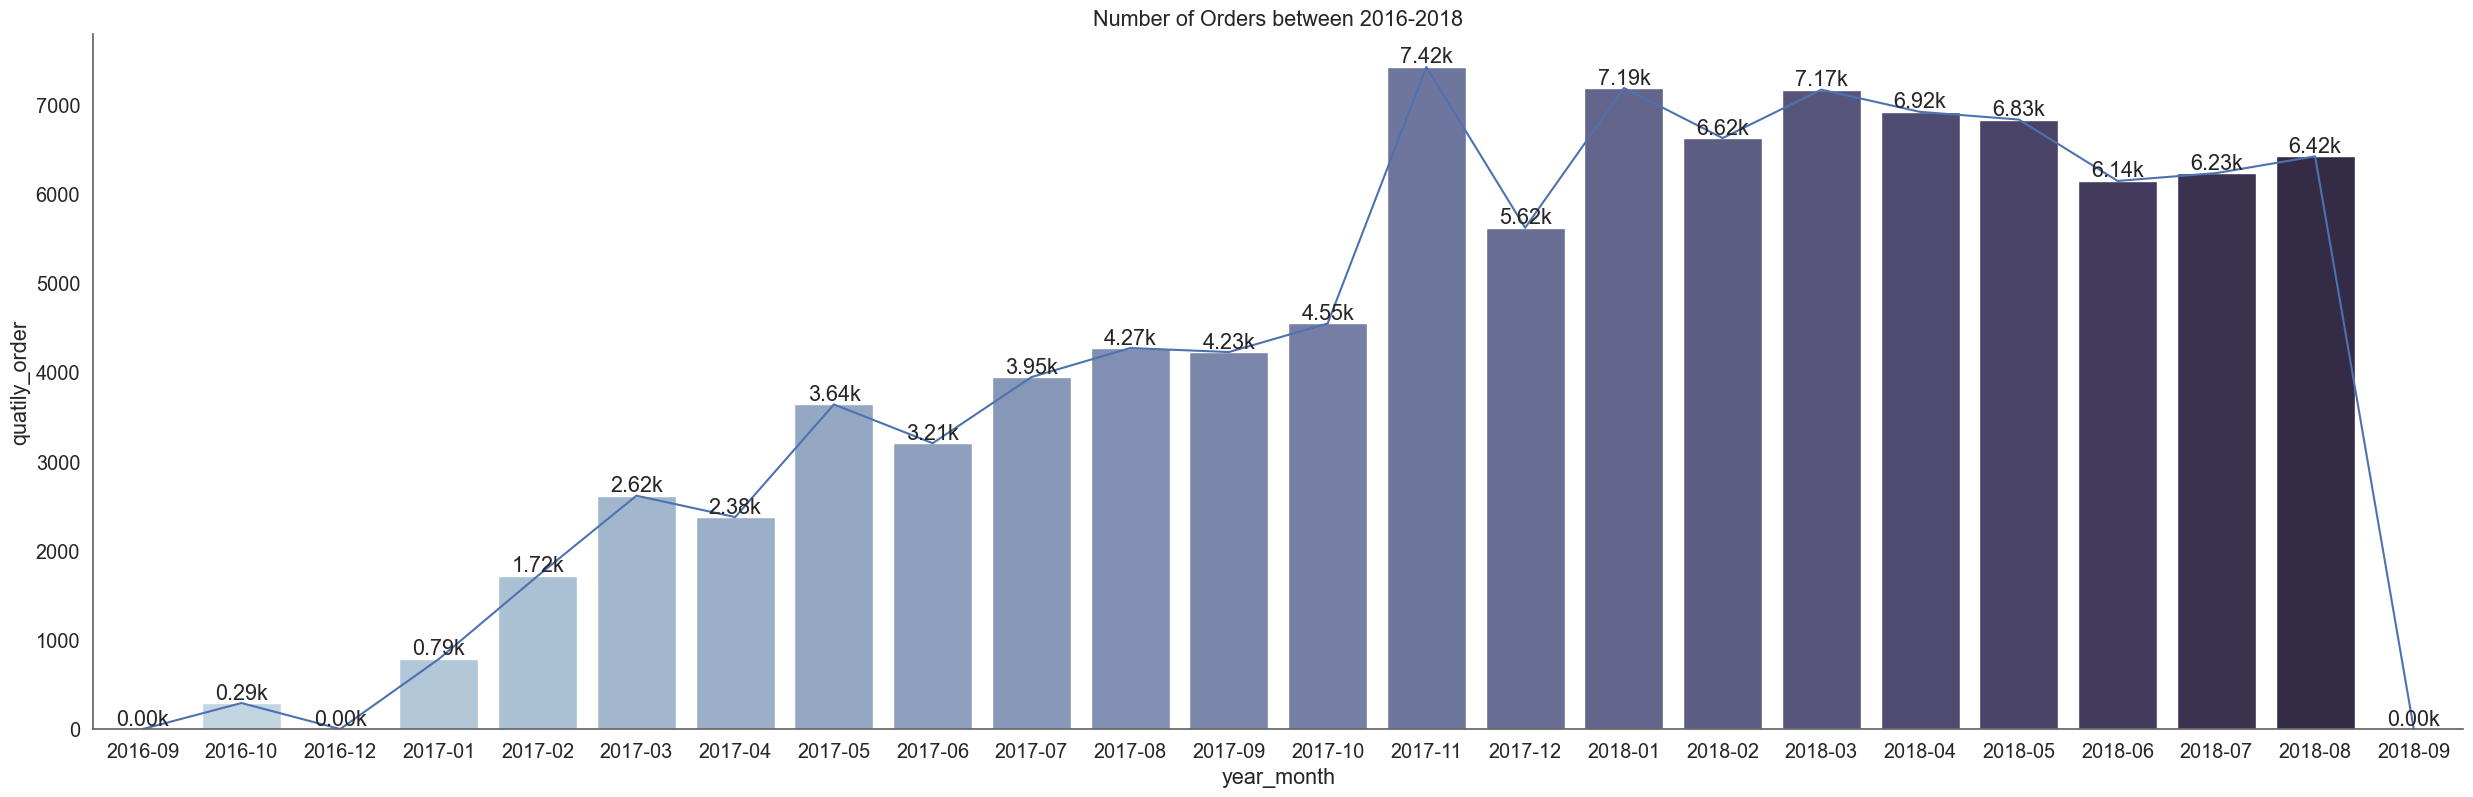

In [57]:
fig, ax = plt.subplots(figsize=(25, 8))
ax = sns.lineplot(x='year_month', y='quatily_order', data=df_revenue_by_month)
bar_plot(x='year_month', y='quatily_order', df=df_revenue_by_month, value=True)
format_spines(ax, right_border=False)
ax.set_title('Number of Orders between 2016-2018');